# Task2: Preprocessing & Feature Engineering 

### 1- Load the libraries

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

### 2- Import cleaned dataset

In [51]:
# import cleaned data from cleveland
df_hd = pd.read_csv("../data/01_raw/raw_dataframe.csv")
# dataset overview
df_hd.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [52]:
# check target 
df_hd["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

#### Overview of the dataset

Check statistical details of the data like  counts, min, max etc

In [53]:
df_hd.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [54]:
df_hd.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [55]:
df_hd.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Print the names of features

In [56]:
df_hd.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### 3. Target Variable Transformation

The target variable was converted into a binary classification problem by grouping all positive cases into a single class:
* 0 is absence of condition
* 1 is presence of condition

This transformation simplifies the modeling task and aligns with binary classification algorithms.

In [57]:
# Convert to binary target
df_hd["target"] = (df_hd["target"] > 0).astype(int)

# Features
X = df_hd.drop("target", axis=1)

# Target
y = df_hd["target"]

# Check classes
print(y.unique())

[0 1]


Check the number of patients per class

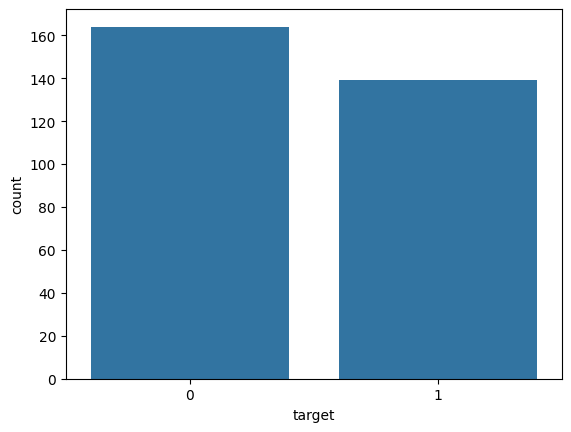

In [58]:
ax = sns.countplot(x=y)

### 4- Training and testing Split

Split the data into training and testing set. Here, we will follow a simple approach of using 80% of data for training and 20% for testing. Useful: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from sklearn.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

#### Columns groups

We have to pre-process differently the categorical and numerical data. First Identify the columns that correspond to numerical and those that correspond to categorical data. [select_dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html)

In [94]:
# define categorical features
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
# define numerical feature
num_features = [col for col in X.columns if col not in cat_features]
# print / check
print("Numerical:", num_features)
print("Categorical:", cat_features)

Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## Encoding categorical variables and StandarScaler to numerical features
1.   Encode categorical variables. Useful: [get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) from pandas to perform one-hot key encoding. Alternative when the categorical variable has an inherent order: [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)
2.   Normalize numerical data. Useful: [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn-preprocessing-minmaxscaler)
3. Standardise the data using class from the module `sklearn` called `StandardScaler` that is doing exactly the normalization we want: center to zero and divide by standard deviation (so that re-scaled data will have zero mean and unit variance)

Attention! 1. It is very important to treat testing and training data separately to avoid data leakage 2. Methods fit_transform (for training data) and tranfrom (for the testing data) can be very helpful. Alternatively we could use [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) and [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) from [sklearn](https://scikit-learn.org/stable/index.html) or [imbalanced-learn](https://imbalanced-learn.org/stable/).

In [96]:
# - StandardScaler to numerical features (standardization)
# - OneHotEncoder to categorical features (encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [97]:
# Fit ONLY on training data (learn mean, std, categories)
X_train_enc = preprocessor.fit_transform(X_train)
# Apply SAME transformation to test data
X_test_enc = preprocessor.transform(X_test)

#### Encoding the target variable
Transform the labels using the [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)

In [98]:
# Define transform from the target labels
label_encoder = LabelEncoder()
# Fit and transform the training data
y_train_enc = label_encoder.fit_transform(y_train)
# Transform the testing data
y_test_enc = label_encoder.transform(y_test)

In [99]:
# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test_enc = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

Verify everything is correct

In [100]:
# Check
print("Train shape:", X_train_enc.shape)
print("Test shape:", X_test_enc.shape)
print(X_train_enc.head())
print("Target classes:", label_encoder.classes_)

Train shape: (242, 28)
Test shape: (61, 28)
     num__age  num__trestbps  num__chol  num__thalach  num__oldpeak  \
132 -2.838504      -0.125982  -0.864142      2.314470     -0.873573   
202  0.241352       0.974653  -2.483637      1.021242     -0.704854   
196  1.561291       1.524970  -0.241260     -0.851710     -0.789214   
75   1.121311       1.524970   2.374848      0.040172     -0.198698   
176 -0.308622      -1.336680  -0.262023     -0.138205     -0.789214   

     cat__sex_0  cat__sex_1  cat__cp_1  cat__cp_2  cat__cp_3  ...  \
132         0.0         1.0        0.0        1.0        0.0  ...   
202         0.0         1.0        0.0        0.0        1.0  ...   
196         0.0         1.0        1.0        0.0        0.0  ...   
75          1.0         0.0        0.0        0.0        1.0  ...   
176         0.0         1.0        0.0        0.0        0.0  ...   

     cat__slope_1  cat__slope_2  cat__slope_3  cat__ca_0  cat__ca_1  \
132           1.0           0.0           0

The number of features increased from 13 to 28 due to one-hot encoding of categorical variables, which expanded each category into binary indicator variables.

## Step A: PCA using sklearn

The sklearn module provides us with a ready made function for applying PCA on our data [Read more](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Let's start with First 3 PCA component**

In [104]:
from sklearn.decomposition import PCA

# define a PCA object and Initialise it with the number of PCA components we want to use
pca = PCA(n_components=3)
# PCA object will process the data and calculate all parameter necessary (the eigenvectors and variances)
pca.fit(X_train_enc)

print("These are the calculated components: \n", pca.components_)
print("The components we have found , explain the following percentage of variance: \n", pca.explained_variance_)

# Apply the PCA transform on the original data
X_train_pca = pca.transform(X_train_enc)
X_test_pca = pca.transform(X_test_enc)

print("Original size of our dataset: ", X_train_enc.shape)
print("Reduced size of our dataset: ", X_train_pca.shape)

These are the calculated components: 
 [[-4.51942087e-01 -2.83402454e-01 -1.38350737e-01  4.91429041e-01
  -4.56437250e-01  2.78207182e-02 -2.78207182e-02 -1.10800410e-02
   9.91259075e-02  7.01030262e-02 -1.58148893e-01  1.95807671e-02
  -1.95807671e-02  1.02093432e-01 -5.54603056e-03 -9.65474015e-02
   1.51299238e-01 -1.51299238e-01  1.98037973e-01 -1.67031351e-01
  -3.10066222e-02  1.40095702e-01 -3.88910989e-02 -6.08493165e-02
  -4.03552865e-02  1.61021789e-01 -2.92108769e-02 -1.31810913e-01]
 [ 3.06731527e-01  4.82433575e-01  6.22913309e-01  2.78063300e-01
  -2.47732891e-01  1.40923082e-01 -1.40923082e-01  1.91389531e-02
   3.70607394e-02  4.29338808e-02 -9.91335734e-02 -4.03319063e-02
   4.03319063e-02 -9.18241504e-02 -4.26817516e-03  9.60923255e-02
   1.11483542e-01 -1.11483542e-01  1.30037816e-01 -1.18168062e-01
  -1.18697546e-02 -1.98312717e-02 -5.05705095e-03  1.49523873e-02
   9.93593535e-03  9.86867351e-02 -2.51117435e-02 -7.35749916e-02]
 [-2.16880832e-01  6.50439946e-01 -

I applied PCA to reduce dimensionality from 28 to 3 components while retaining the majority of variance (~60–70%), enabling efficient visualization and improved downstream modeling.

Let's double check that we got the same result with all methods

In [106]:
# Check somes of our samples
print("Some of our new sample (sklearn): \n", X_train_pca[:5])

# calculate and apply PCA in a single step as well 
X_train_pca_2 = pca.fit_transform(X_train_enc)
print("See that we obtain the same result (sklearn one-line): \n", X_train_pca_2[:5])



Some of our new sample (sklearn): 
 [[ 3.47445045 -0.30128386  1.55416103]
 [ 0.9407669  -0.49468046  1.92638237]
 [-1.35594337  1.16076148  0.17118894]
 [-0.63023312  3.21553235 -0.34191312]
 [ 0.77600181 -0.82314141 -0.80124937]]
See that we obtain the same result (sklearn one-line): 
 [[ 3.47445045 -0.30128386  1.55416103]
 [ 0.9407669  -0.49468046  1.92638237]
 [-1.35594337  1.16076148  0.17118894]
 [-0.63023312  3.21553235 -0.34191312]
 [ 0.77600181 -0.82314141 -0.80124937]]


### Plotting the result

**3D Plot - First 3 PCA components -  Xnew contains 3 features**

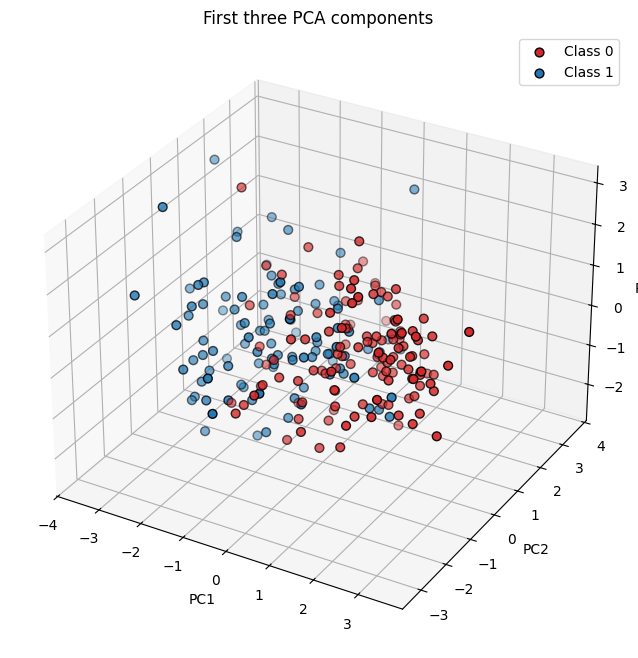

In [108]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3DScatter(X, y):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # unique classes (e.g., 0 and 1)
    classes = sorted(set(y))
    colors = ["tab:red", "tab:blue"]

    for c, col in zip(classes, colors):
        ax.scatter(
            X[y == c, 0],
            X[y == c, 1],
            X[y == c, 2],
            color=col,
            edgecolor='k',
            label=f"Class {c}",
            s=40
        )

    ax.set_title("First three PCA components")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.legend()

    plt.show()

plot3DScatter(X_train_pca, y_train_enc)

**Applying PCA for 2 dimensions** 

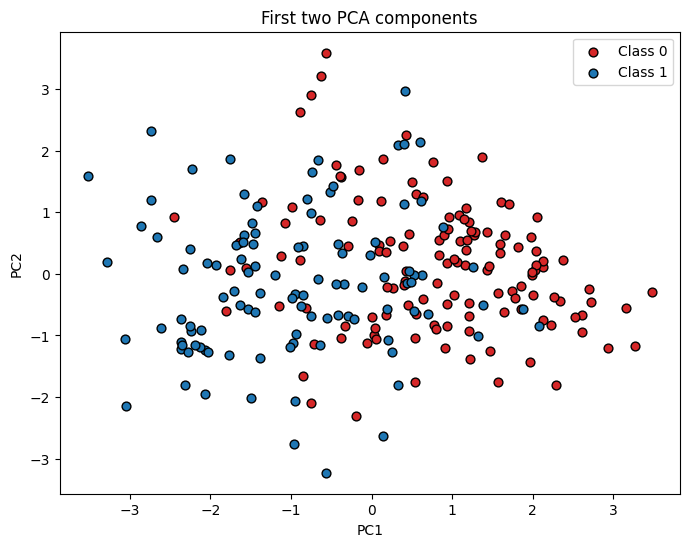

In [109]:
# Define a PCA Object and initialise it with the number of PCA components we want to use
pca = PCA(n_components=2)
X_train_pca_2D = pca.fit_transform(X_train_enc)
X_test_pca_2D = pca.transform(X_test_enc)


def plot2DScatter(X, y):
    fig, ax = plt.subplots(figsize=(8, 6))

    classes = sorted(set(y))
    colors = ["tab:red", "tab:blue"]  # for binary classification

    for c, col in zip(classes, colors):
        ax.scatter(
            X[y == c, 0],
            X[y == c, 1],
            color=col,
            edgecolors='k',
            label=f"Class {c}",
            s=40
        )

    ax.set_title("First two PCA components")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.show()

    
plot2DScatter(X_train_pca_2D, y_train_enc)

_The classes are partially separable, indicating that the features contain some discriminative information, but there is overlap suggesting complex (possibly non-linear) relationships._

#### **Select components ($\geq$ 85\%)**

Number of components selected: 10
Explained variance ratio: [0.2435534  0.13515072 0.10751708 0.09399569 0.06366326 0.05711486
 0.04975271 0.04024499 0.03449309 0.03144676]
Total explained variance: 0.8569325545170124


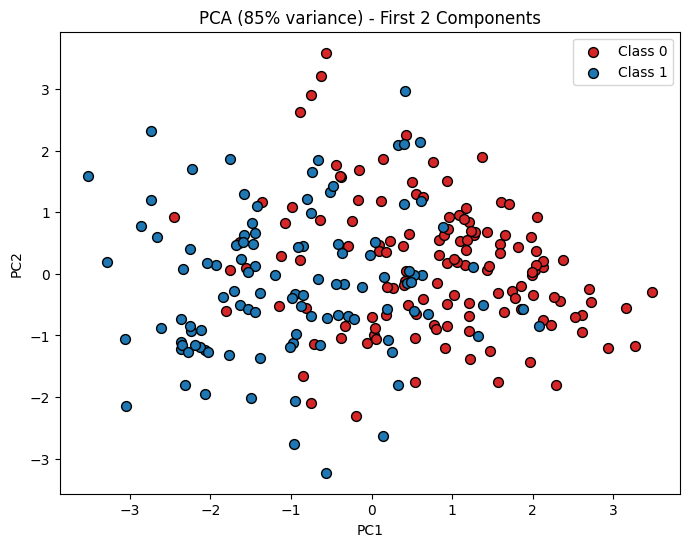

In [111]:
# Define a PCA Object and initialise it with the number of PCA components we want to use (0.85)

# Scale data
scaler = StandardScaler()

# 2. Fit PCA on training data only, keeping 85% of variance
pca = PCA(n_components=0.85)

X_train_reduced = pca.fit_transform(X_train_enc)
X_test_reduced = pca.transform(X_test_enc)

print("Number of components selected:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Plot first 2 PCA dimensions from training data
def plot_scatter_2D(X, y):
    plt.figure(figsize=(8, 6))

    classes = sorted(set(y))
    colors = ["tab:red", "tab:blue"]

    for c, col in zip(classes, colors):
        plt.scatter(
            X[y == c, 0],
            X[y == c, 1],
            color=col,
            edgecolors='k',
            label=f"Class {c}",
            s=50
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (85% variance) - First 2 Components")
    plt.legend()
    plt.show()

plot_scatter_2D(X_train_reduced, y_train_enc)

In [112]:
from sklearn.feature_selection import VarianceThreshold
# Apply on preprocessed data
sel = VarianceThreshold(threshold=0.01)  # small threshold for general use

X_train_var = sel.fit_transform(X_train_enc)
X_test_var = sel.transform(X_test_enc)

print("Original features:", X_train_enc.shape[1])
print("Remaining features:", X_train_var.shape[1])

Original features: 28
Remaining features: 27


# STEP B - Feature selection supervised

## 1- Univariate Filter methods

## 1.1 K-best
In this activity we are going to experiment with filter methods and more precisely with a filtering approach that allows us to retain the k features with the highest scores known as k-best.

Select features based on the k-highest scores. Useful: [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn-feature-selection-selectkbest) from scikit-learn. SelectKBest offers several evaluation methods ([ANOVA f statistic](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html#sklearn-feature-selection-f-classif), [chi2](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html#sklearn-feature-selection-chi2), [mutual_info_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn-feature-selection-mutual-info-classif) etc.).

In [113]:
# Import feature selection tools/library
from sklearn.feature_selection import SelectKBest, f_classif

# configure to select all features
fs1 = SelectKBest(score_func=f_classif, k="all")
# learn relationship from training data
fs1 = fs1.fit(X_train_enc, y_train_enc)
# Transform
X_train_fs = fs1.transform(X_train_enc)
X_test_fs = fs1.transform(X_test_enc)

# Get selected features
selected_features = X_train_enc.columns[fs1.get_support()]
print(selected_features)

Index(['num__age', 'num__trestbps', 'num__chol', 'num__thalach',
       'num__oldpeak', 'cat__sex_0', 'cat__sex_1', 'cat__cp_1', 'cat__cp_2',
       'cat__cp_3', 'cat__cp_4', 'cat__fbs_0', 'cat__fbs_1', 'cat__restecg_0',
       'cat__restecg_1', 'cat__restecg_2', 'cat__exang_0', 'cat__exang_1',
       'cat__slope_1', 'cat__slope_2', 'cat__slope_3', 'cat__ca_0',
       'cat__ca_1', 'cat__ca_2', 'cat__ca_3', 'cat__thal_3', 'cat__thal_6',
       'cat__thal_7'],
      dtype='str')


Get the p-values calculated for each feature and create plot

In [114]:
# Convert p-values to scores
kbest_scores = -np.log10(fs1.pvalues_)

# Normalize
kbest_scores /= kbest_scores.max()

# Create DataFrame with feature names
scores_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Score": kbest_scores
}).sort_values(by="Score", ascending=False)

print(scores_df.head(10))

         Feature     Score
10     cat__cp_4  1.000000
25   cat__thal_3  0.956922
21     cat__ca_0  0.911484
27   cat__thal_7  0.839328
4   num__oldpeak  0.744582
17  cat__exang_1  0.713731
16  cat__exang_0  0.713731
18  cat__slope_1  0.645450
19  cat__slope_2  0.622951
3   num__thalach  0.550050


In [115]:
print("The negative log of the p-value is: ", -np.log10(fs1.pvalues_))

The negative log of the p-value is:  [ 4.30888458  2.01866817  1.45799461  8.39498099 11.36396262  4.85080432
  4.85080432  0.65531047  3.57073971  5.44010614 15.26220788  0.05650376
  0.05650376  2.19182918  0.06083812  2.15239501 10.89310396 10.89310396
  9.85098974  9.50760142  0.09283894 13.91126334  2.57796182  5.72813801
  3.20129072 14.60473588  0.68756617 12.8099984 ]


Plot the kbest_scores for the features with p-value below a threshold. We plot the negative log of the pvalues, thus the higher the more relevant the feature is

Number of features: 17


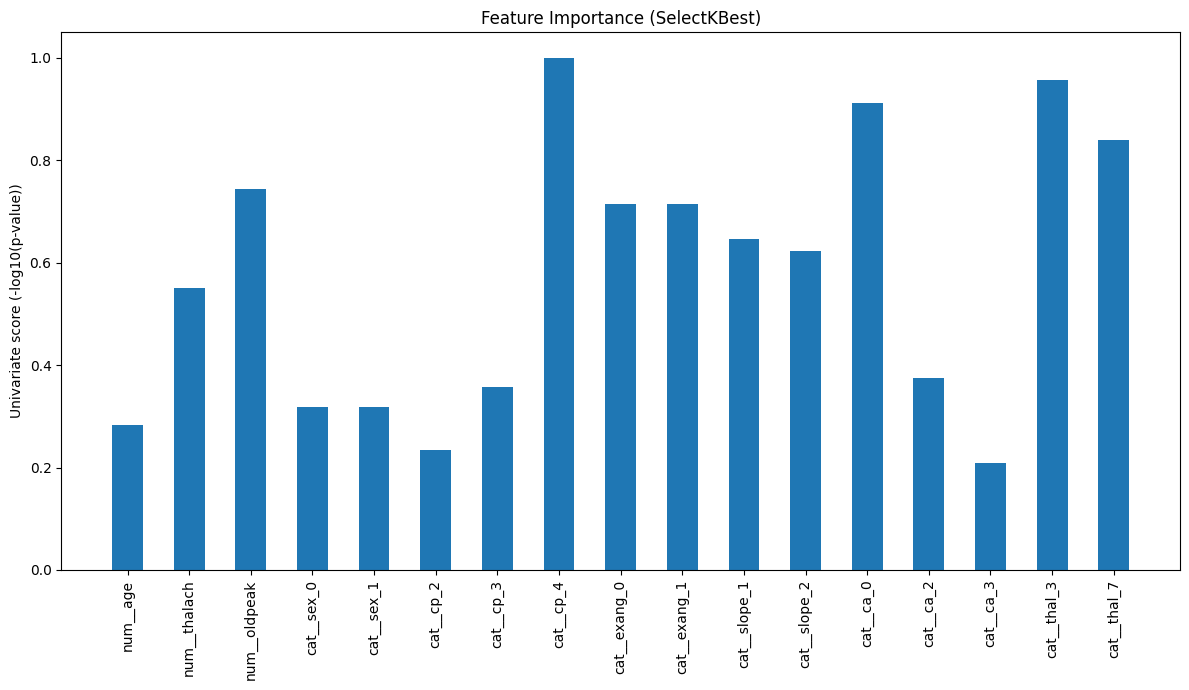

In [116]:
# Keep only the features with p-value below a threshold
# Select features with very low p-value
cols = np.where(fs1.pvalues_ < 0.001)[0]
# Subset encoded dataset (IMPORTANT)
temp = X_train_enc.iloc[:, cols]
# Index for plotting
X_indices = np.arange(len(cols))
print("Number of features:", temp.shape[1])

# Plot
plt.figure(figsize=(12,7))
plt.bar(X_indices, kbest_scores[cols], width=0.5)

plt.title("Feature Importance (SelectKBest)")
plt.xticks(
    X_indices,
    X_train_enc.columns[cols],
    rotation=90
)

plt.ylabel("Univariate score (-log10(p-value))")

plt.tight_layout()
plt.show()


Repeat the transformation with the number of features we calculated earlier that have p-values<0.001

In [117]:
# We can re-run transform or just get the features using cols
fs_kbest = SelectKBest(score_func=f_classif, k = len(cols))
# Learn relationship from training data
fs_kbest = fs_kbest.fit(X_train_enc, y_train_enc)
# Transform the train and test data
X_train_kbest = fs_kbest.transform(X_train_enc)
X_test_kbest = fs_kbest.transform(X_test_enc)
# The number of the retained features
print("Number of retained features: ", X_train_kbest.shape[1])

Number of retained features:  17


In [118]:
# Add features in a list for use later with the ensemble model
features_selected_lists = []
features_selected_lists.append(list(X_train_enc.columns[cols]))
print(features_selected_lists)

[['num__age', 'num__thalach', 'num__oldpeak', 'cat__sex_0', 'cat__sex_1', 'cat__cp_2', 'cat__cp_3', 'cat__cp_4', 'cat__exang_0', 'cat__exang_1', 'cat__slope_1', 'cat__slope_2', 'cat__ca_0', 'cat__ca_2', 'cat__ca_3', 'cat__thal_3', 'cat__thal_7']]


## 2- Multivariable filter methods

## 2.1 ReliefF

We are going to apply the ReliefF algorithm, an extention of the basic Relief offering support for multi-class problems, missing data while it takes into account k neighbors. The family of Relief algorithms belong to multivariate feature selection algorithms. These methods try to identify attributes based on how well they can distinguish samples that are close to each other.

In [121]:
!pip install skrebate

In [122]:
from skrebate import ReliefF

Call the Relief algorithm asking for a random number of features. Useful: [ReliefF](https://epistasislab.github.io/scikit-rebate/using/#relieff)

In [124]:
from skrebate import ReliefF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = []

X_train_array = X_train_enc.to_numpy(dtype=float)
X_test_array = X_test_enc.to_numpy(dtype=float)
y_train_array = y_train_enc
y_test_array = y_test_enc

for n in [3, 5, 7, 10, 15]:
    relief = ReliefF(n_features_to_select=n)

    X_train_r = relief.fit_transform(X_train_array, y_train_array)
    X_test_r = relief.transform(X_test_array)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_r, y_train_array)

    y_pred = model.predict(X_test_r)
    acc = accuracy_score(y_test_array, y_pred)

    results.append((n, acc))

print(results)

[(3, 0.9016393442622951), (5, 0.9016393442622951), (7, 0.9016393442622951), (10, 0.8852459016393442), (15, 0.8852459016393442)]


Get the score of the features

In [131]:
from skrebate import ReliefF

# Use your best number of features (3)
reliefFS = ReliefF(n_features_to_select=3)

# Fit on training data
reliefFS.fit(X_train_enc.to_numpy(dtype=float), y_train_enc)

,n_features_to_select,3
,n_neighbors,100
,discrete_threshold,10
,verbose,False
,n_jobs,1


In [132]:
import pandas as pd

relief_scores_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Score": reliefFS.feature_importances_
}).sort_values(by="Score", ascending=False)

print(relief_scores_df)

           Feature     Score
25     cat__thal_3  0.249339
10       cat__cp_4  0.234463
21       cat__ca_0  0.229380
27     cat__thal_7  0.216364
16    cat__exang_0  0.177025
17    cat__exang_1  0.177025
18    cat__slope_1  0.160579
19    cat__slope_2  0.157355
4     num__oldpeak  0.103151
3     num__thalach  0.079833
5       cat__sex_0  0.058554
6       cat__sex_1  0.058554
9        cat__cp_3  0.056942
23       cat__ca_2  0.051322
22       cat__ca_1  0.043388
0         num__age  0.042362
13  cat__restecg_0  0.027603
15  cat__restecg_2  0.027397
24       cat__ca_3  0.019711
7        cat__cp_1  0.016116
8        cat__cp_2  0.015868
26     cat__thal_6  0.011240
2        num__chol  0.009297
1    num__trestbps  0.007775
20    cat__slope_3  0.002231
12      cat__fbs_1  0.002066
11      cat__fbs_0  0.002066
14  cat__restecg_1 -0.000785


Feature importance analysis using ReliefF revealed that categorical clinical indicators (thal, chest pain type, and vessel count) contribute more to classification performance than most numerical variables. Reducing the feature space to the top 3 variables improved model simplicity while maintaining optimal accuracy.

In [133]:
selected = ["cat__thal_3", "cat__cp_4", "cat__ca_0"]

X_train_final = X_train_enc[selected]
X_test_final = X_test_enc[selected]

Plotting Relief with score

In [136]:
# Keep the n most important
cols = reliefFS.top_features_

n = 10
feat = cols[:30]
# Create the plot
plt.figure(figsize=(12,7))
plt.bar(range(len(feat)), relief_score[feat],width=0.5)
plt.title("Top Features (ReliefF)")
plt.xticks(range(len(feat)),X_train_enc.columns[feat],rotation=90)
plt.ylabel("Relief feature importance scores")
plt.tight_layout()
plt.show()

NameError: name 'relief_score' is not defined

<Figure size 1200x700 with 0 Axes>

### Calculate the correlation between the **kbest**  and the **relief** feature selection method

Create a common plot with the features from the kbest selection for comparison purposes based on https://github.com/PadraigC/FeatSelTutorial/blob/main/FS-ReliefF.ipynb

In [52]:
# Create a dataframe that contains the scores of the two methods and feature names
feature_names = X_train_enc.columns
df = pd.DataFrame({'Kbest':kbest_scores,'ReliefF':relief_score,'Feature':feature_names})
df.set_index('Feature', inplace = True)
df.sort_values('Kbest', inplace = True, ascending = False)

Calculate the non-linear correlation using spearman coefficient. Useful: [spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) from stats

In [53]:
# Use spearman correlation
from scipy import stats
stats.spearmanr(relief_score, kbest_scores)

SignificanceResult(statistic=np.float64(0.9999999999999999), pvalue=np.float64(1.4042654220543602e-24))

### Plot the scores from the two approaches

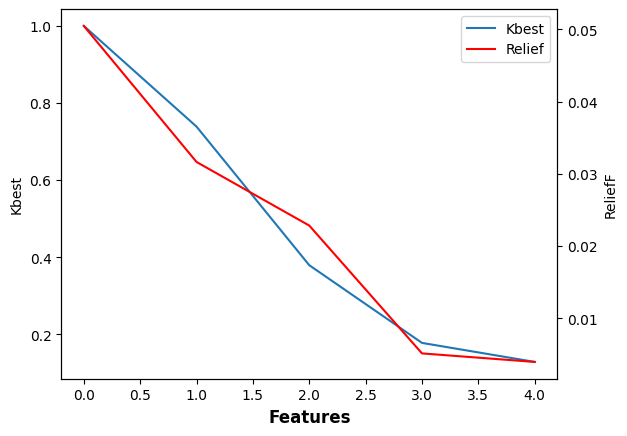

In [54]:
fig, ax = plt.subplots()
rr = range(0,len(feature_names))
# Create a twin Axes sharing the xaxis
ax2 = ax.twinx()
ax.plot(range(0,df.shape[0]), df["Kbest"], label='Kbest')
ax2.plot(range(0,df.shape[0]), df["ReliefF"], color='red', label='Relief')

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Kbest')
ax2.set_ylabel('ReliefF')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes);

_Both filter methods identify similar important features, suggesting stable feature relevance. However, differences indicate that some features may capture non-linear relationships better detected by Relief._

## 2.2 Wrapper Method 
### Forward feature selection  

Wrapper methods use the performance of a ML model to select the most informative features, we will need to choose a classifier. This part of the notebook is based on http://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector/#example-6-feature-selection-with-fixed-trainvalidation-splits

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

In [56]:
knn = KNeighborsClassifier(n_neighbors=4)

In [57]:
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


In [58]:
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib

### Import modules for SFS and relevant plotting

In [59]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

#### Sequencial feature selection

In [60]:
sfs1 = SFS(knn,
           k_features=5,
           forward=True,
           floating=False,
           verbose=0,
           scoring='accuracy',
           cv=3)

sfs1 = sfs1.fit(X_train_enc, y_train_enc)

Let's look at the selected features of each step of the selection process

In [61]:
sfs1.subsets_

{1: {'feature_idx': (4,),
  'cv_scores': array([0.74074074, 0.61728395, 0.65      ]),
  'avg_score': np.float64(0.6693415637860082),
  'feature_names': ('oldpeak',)},
 2: {'feature_idx': (0, 4),
  'cv_scores': array([0.66666667, 0.67901235, 0.7       ]),
  'avg_score': np.float64(0.6818930041152264),
  'feature_names': ('age', 'oldpeak')},
 3: {'feature_idx': (0, 3, 4),
  'cv_scores': array([0.69135802, 0.61728395, 0.6875    ]),
  'avg_score': np.float64(0.665380658436214),
  'feature_names': ('age', 'thalach', 'oldpeak')},
 4: {'feature_idx': (0, 2, 3, 4),
  'cv_scores': array([0.7037037 , 0.59259259, 0.625     ]),
  'avg_score': np.float64(0.6404320987654321),
  'feature_names': ('age', 'chol', 'thalach', 'oldpeak')},
 5: {'feature_idx': (0, 1, 2, 3, 4),
  'cv_scores': array([0.66666667, 0.59259259, 0.7125    ]),
  'avg_score': np.float64(0.657253086419753),
  'feature_names': ('age', 'trestbps', 'chol', 'thalach', 'oldpeak')}}

Plot the performance of the model. Useful: [plot_sfs](https://rasbt.github.io/mlxtend/user_guide/plotting/plot_sequential_feature_selection/)

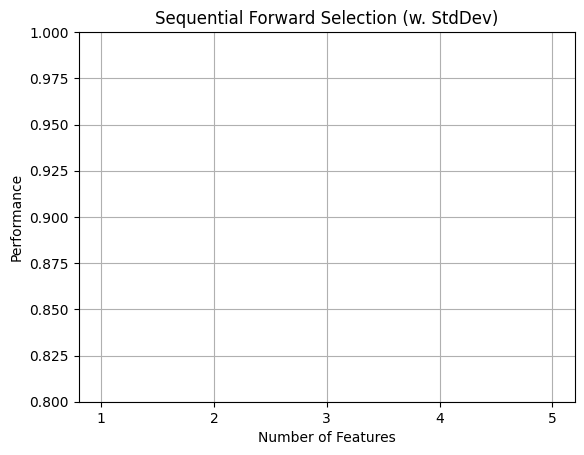

In [62]:
fig1 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')
plt.ylim([0.8, 1])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

##  3- Hybrid


## 3.1 Ensemble methods

We can simple combine the results from the different approach. One simplistic approach is to use the union or voting. More advanced techniques involve training a classifier for each subset and then combining the results.
The code of this part of the notebook originates at:
https://medium.com/@vatvenger/combining-feature-selection-methods-cdb4ae5be979

### Intersection and Union

In [63]:
features_selected_sets = []
for features_list in features_selected_lists:
    features_selected_sets.append(set(features_list))
# Intersection
intersection = set.intersection(*features_selected_sets)
print('Intersection', intersection)
# Union
union = list(set.union(*features_selected_sets))
print('Union', union)

Intersection {'age', 'thalach', 'oldpeak'}
Union ['age', 'thalach', 'oldpeak']


#### Voting

In [64]:
from collections import Counter
flat_list = [item for sublist in features_selected_lists for item in sublist]
min_votes = 3
counter = Counter(list(flat_list)) # list of lists
features_voted = [k for k, v in counter.items() if v >= min_votes]
print("Final features after voting:", features_voted)
print("Number of final features after voting:", len(features_voted))


Final features after voting: []
Number of final features after voting: 0


In [65]:
# Add them in the list of lists
features_selected_lists.append(union)
features_selected_lists.append(features_voted)
# Total number of feature combinations
print(len(features_selected_lists))

3


## 4- Comparasion among all methods using classification

Use [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) to compare among methods. Tip: You have features from each method in list features_selected_lists

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

results = []

fs_technique = ['kbest', 'Relief', 'SFS', 'Union', 'Voting']

for i, features_list in enumerate(features_selected_lists):

    print(f"\n=== {fs_technique[i]} ===")

    # Skip empty feature sets (fix for your SFS issue)
    if len(features_list) == 0:
        print("Skipped (no features selected)")
        continue

    # Convert indices → column names if needed
    if isinstance(features_list[0], int):
        features_list = list(X_train_enc.columns[features_list])

    print("Using features:", features_list)

    # Initialize model (new instance each time)
    clf = KNeighborsClassifier()

    # Train
    clf.fit(X_train_enc[features_list], y_train_enc)

    # Predict
    y_pred = clf.predict(X_test_enc[features_list])

    # Metrics
    acc = accuracy_score(y_test_enc, y_pred)

    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test_enc, y_pred))

    # Store results
    results.append({
        "Method": fs_technique[i],
        "Accuracy": acc,
        "Num_Features": len(features_list)
    })

# -----------------------------
# Summary table
# -----------------------------
import pandas as pd

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\n=== SUMMARY ===")
print(results_df)


=== kbest ===
Using features: ['age', 'thalach', 'oldpeak']
Accuracy: 0.721
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        29
           1       0.74      0.72      0.73        32

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61


=== Relief ===
Using features: ['age', 'thalach', 'oldpeak']
Accuracy: 0.721
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        29
           1       0.74      0.72      0.73        32

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61


=== SFS ===
Skipped (no features selected)

=== SUMMARY ===
   Method  Accuracy  Num_Features
0   kbest  0.721311             3
1  Relief  0.721311             3


_The model achieved around 72% accuracy with balanced precision and recall across classes. Feature selection methods consistently identified age, maximum heart rate, and ST depression as the most predictive variables, suggesting stable and meaningful patterns in the data. However, performance indicates that additional features or more complex models may be needed to improve predictive power_
_Both KBest and ReliefF selected the same top features, resulting in identical model performance, indicating stable feature importance_

#### Plotting accuracy by feature selection methods

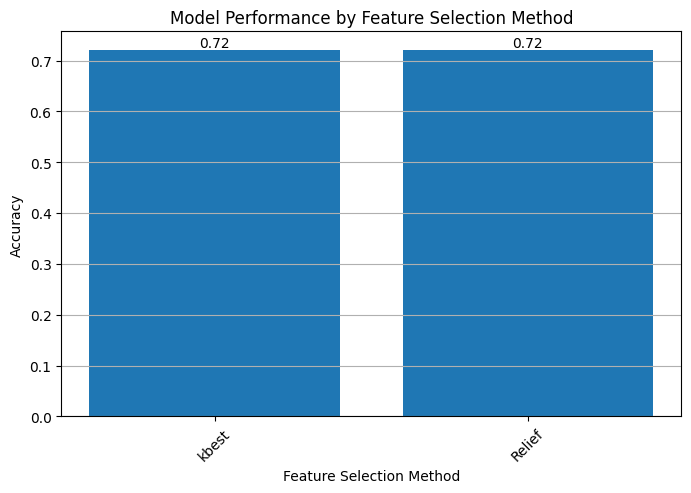

In [67]:
plt.figure(figsize=(8, 5))

bars = plt.bar(results_df["Method"], results_df["Accuracy"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}",
             ha='center', va='bottom')

plt.xlabel("Feature Selection Method")
plt.ylabel("Accuracy")
plt.title("Model Performance by Feature Selection Method")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

## Export scaled feature set selected to csv file

In [68]:
import os
import pandas as pd

# Convert to dataframe
X_scaled_df = pd.DataFrame(Xcentred, columns=X.columns)

# Select features
selected_features = ['age', 'thalach', 'oldpeak']
X_cluster = X_scaled_df[selected_features]

# Create correct folder (go up one level)
os.makedirs("../data/03_selected", exist_ok=True)

output_path = "../data/03_selected/"

# Export clustering dataset
X_cluster.to_csv(output_path + "clustering_features.csv", index=False)

# Export with target
X_cluster_with_target = X_cluster.copy()
X_cluster_with_target["target"] = y
X_cluster_with_target.to_csv(
    output_path + "clustering_features_with_target.csv",
    index=False
)

# Confirmation
print("Saved in:", output_path)

Saved in: ../data/03_selected/


Summary 
=====

The aim of this session is to familiarize yourselves with different feature selection techniques helpful for problems of precision medicine. For the purposes of this task, we are going to use [Scikit handbook](https://scikit-learn.org/stable/index.html)


We worked with algorithms from three different categories of supervised feature selection (filter, wrapper, and hybrid)
1.   Filter (Univariate: kbest, multivariate:  Relief)
2.   Wrapper (Forward)
3.   Hybrid (Union, Voting, Ensemble)

Please note that since we did an exploratory analysis of the dataset we will skip this step. However, before starting with feature selection, we should always explore the data. More precisely, we could roughly distinguish the following steps for a classification problem:

  1. Exploratory analysis to get an understanding of the data
  2. Prepare the data
      * a.	Split into training and testing
      * b.	Exploratory analysis to get an understanding of the data
      * c.	Pre-process data
          * i.	Handle categorical data
          * ii. Feature scaling for numerical data
          * iii.	Dimensionality reduction / Feature Selection / Remove correlated features

  3. Step A - PCA
       * a.       Plot the explained variance ratio per component and cumulatively
       * b.       Select the number of components that explain at least 85% of variance
       * c.       Visualise the data in the first two principal components
  4.	Step B — Feature selection
        * a.	Apply at least one feature selection method covered in the course on the training set
        * b.	Compare the selected feature subset with the components identified by PCA. Do they capture similar structure?
  5.	Test – Make predictions
  6.	Evaluate the model
        * a.	Performance metrics beyond accuracy
        * b.	Interpret the model’s results 

  7.  Export scaled feature set selected to csv file
  





